Varshini Narayanan

This code contains the analysis for non stress days. AI used for table formatting.

102 lines of code

In [1]:
import pandas as pd
import numpy as np

In [2]:
inst_data = pd.read_csv('str_vol_inst_data.csv')

In [14]:
inst_data['date'] = pd.to_datetime(inst_data['date'])
inst_data['quarter'] = inst_data['date'].dt.to_period('Q')

In [ ]:


level_data = pd.read_csv("str_vol_inst_data.csv")

inst_data['date'] = pd.to_datetime(inst_data['date'])
inst_data['quarter'] = inst_data['date'].dt.to_period('Q')

# volatility groups
inst_data['vol_pct'] = inst_data['market_volatility'].rank(pct=True)

def assign_vol_group(p):

    if p <= 0.3:
        return "very_low"
    elif p <= 0.6:
        return "low"
    elif p <= 0.9:
        return "elevated"
    else:
        return "stress" #still top 10% like other analysis

inst_data['vol_group'] = inst_data['vol_pct'].apply(assign_vol_group)


In [ ]:
#sector mapping same as OwnershipNetowrk.ipynb, not included in code count
#%pip install yfinance

import yfinance as yf

unique_tickers = inst_data['ticker'].dropna().astype(str).unique()

sector_map = {}

for t in unique_tickers:
    try:
        info = yf.Ticker(t).info
        sector_map[t] = info.get("sector")
    except:
        sector_map[t] = None

print(sector_map)

{'AAPL': 'Technology', 'AMZN': 'Consumer Cyclical', 'ASML': 'Technology', 'AVGO': 'Technology', 'BAC': 'Financial Services', 'BRK': None, 'GOOG': 'Communication Services', 'JNJ': 'Healthcare', 'JPM': 'Financial Services', 'LLY': 'Healthcare', 'MA': 'Financial Services', 'META': 'Communication Services', 'MSFT': 'Technology', 'MU': 'Technology', 'NVDA': 'Technology', 'TSLA': 'Consumer Cyclical', 'TSM': 'Technology', 'V': 'Financial Services', 'WMT': 'Consumer Defensive', 'XOM': 'Energy'}


In [16]:
sector_df = pd.DataFrame(
    list(sector_map.items()),
    columns=["ticker","sector"]
)

In [17]:
#ownership network same as OwnershipNetwork.ipynb (not included in code count)
all_overlap_results = []

for q in inst_data['quarter'].unique():
    
    quarter_data = inst_data[inst_data['quarter'] == q].copy()
    
    if quarter_data['ticker'].nunique() < 2:
        continue
    
    quarter_data = quarter_data.drop_duplicates(
        subset=['ticker','mgrno']
    )

    firm_inst_matrix = quarter_data.pivot_table(
        index='ticker',
        columns='mgrno',
        values='ownership_pct',
        fill_value=0
    )
    
    W = firm_inst_matrix.values
    
    overlap_matrix = W @ W.T
    
    overlap_df = pd.DataFrame(
        overlap_matrix,
        index=firm_inst_matrix.index,
        columns=firm_inst_matrix.index
    )
    
    np.fill_diagonal(overlap_df.values, 0)
    
    overlap_long = pd.DataFrame({
        'firm_i': np.repeat(overlap_df.index.values, len(overlap_df.columns)),
        'firm_j': np.tile(overlap_df.columns.values, len(overlap_df.index)),
        'ownership_overlap': overlap_df.values.flatten()
    })
    
    overlap_long = overlap_long[
        (overlap_long['firm_i'] != overlap_long['firm_j']) &
        (overlap_long['ownership_overlap'] > 0)
    ]
    
    overlap_long['quarter'] = q
    
    all_overlap_results.append(overlap_long)

ownership_network = pd.concat(all_overlap_results, ignore_index=True)

In [ ]:
#get correlations for all levels
corr_results = []

for (q, group_level), group in inst_data.groupby(['quarter','vol_group']):

    ret_matrix = group.pivot_table(
        index='date',
        columns='ticker',
        values='daily_returns'
    )

    corr_matrix = ret_matrix.corr()

    # remove column/index name conflict
    corr_matrix.index.name = 'firm_i'
    corr_matrix.columns.name = 'firm_j'

    corr_pairs = corr_matrix.stack().reset_index(name='correlation')

    corr_pairs = corr_pairs[corr_pairs['firm_i'] < corr_pairs['firm_j']]

    corr_pairs['quarter'] = q
    corr_pairs['vol_group'] = group_level

    corr_results.append(corr_pairs)

vol_corr_df = pd.concat(corr_results, ignore_index=True)

In [19]:
#merge with ownership netowrk 
analysis_df = ownership_network.merge(
    vol_corr_df,
    on=['firm_i','firm_j','quarter'],
    how='inner'
)

In [20]:
#adding sector infor to the firm-firm pairs
analysis_df = analysis_df.merge(
    sector_df.rename(columns={"ticker":"firm_i","sector":"sector_i"}),
    on="firm_i",
    how="left"
)

analysis_df = analysis_df.merge(
    sector_df.rename(columns={"ticker":"firm_j","sector":"sector_j"}),
    on="firm_j",
    how="left"
)

In [ ]:
corr_results = []

#For every quarter and volatility group, compute the return correlations between all stock pairs
for (q, group_level), group in inst_data.groupby(['quarter','vol_group']):

    ret_matrix = group.pivot_table(
        index='date',
        columns='ticker',
        values='daily_returns'
    )

    corr_matrix = ret_matrix.corr()

    corr_matrix.index.name = 'firm_i'
    corr_matrix.columns.name = 'firm_j'

    corr_pairs = corr_matrix.stack().reset_index(name='correlation')

    corr_pairs = corr_pairs[corr_pairs['firm_i'] < corr_pairs['firm_j']]

    corr_pairs['quarter'] = q
    corr_pairs['vol_group'] = group_level

    corr_results.append(corr_pairs)

vol_corr_df = pd.concat(corr_results, ignore_index=True)

In [11]:
analysis_df = ownership_network.merge(
    vol_corr_df,
    on=['firm_i','firm_j','quarter'],
    how='inner'
)

In [21]:
#control by industry 
analysis_df["same_sector"] = (
    analysis_df["sector_i"] == analysis_df["sector_j"]
).astype(int)

analysis_df["sector_pair"] = (
    analysis_df["sector_i"].astype(str) + "_" +
    analysis_df["sector_j"].astype(str)
)

In [23]:
#regression for all volatility groups including industry controls
import statsmodels.api as sm
from IPython.display import display

for group in sorted(analysis_df["vol_group"].dropna().unique()):

    subset = analysis_df[analysis_df["vol_group"] == group]

    X = subset[["ownership_overlap","same_sector"]]
    X = sm.add_constant(X)

    y = subset["correlation"]

    model = sm.OLS(y, X).fit()

    print("\n===== Volatility Group:", group, "=====") #asked AI how to format
    display(model.summary())


===== Volatility Group: elevated =====


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            correlation   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     99.23
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           9.39e-42
Time:                        23:18:07   Log-Likelihood:                -202.84
No. Observations:                1939   AIC:                             411.7
Df Residuals:                    1936   BIC:                             428.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4239      0.018     23.364      0.000       0.388       0.459
ownership_overlap     7.5854      1.341      5.655      0.000       4.955      10.216
same_sector           0.2083      0.017     12.600      0.000       0.176       0.241
==============================================================================
Omnibus:                      249.483   Durbin-Watson:                   1.411
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              372.390
Skew:                          -0.923   Prob(JB):                     1.37e-81
Kurtosis:                       4.096   Cond. No.                         223.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


===== Volatility Group: low =====


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            correlation   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     117.6
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           6.28e-49
Time:                        23:18:07   Log-Likelihood:                -546.51
No. Observations:                1939   AIC:                             1099.
Df Residuals:                    1936   BIC:                             1116.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.1657      0.022      7.649      0.000       0.123       0.208
ownership_overlap     4.8095      1.601      3.003      0.003       1.669       7.950
same_sector           0.2935      0.020     14.868      0.000       0.255       0.332
==============================================================================
Omnibus:                       15.441   Durbin-Watson:                   1.738
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               15.560
Skew:                          -0.207   Prob(JB):                     0.000418
Kurtosis:                       2.857   Cond. No.                         223.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


===== Volatility Group: stress =====


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            correlation   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     10.45
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           3.10e-05
Time:                        23:18:07   Log-Likelihood:                -1488.9
No. Observations:                1578   AIC:                             2984.
Df Residuals:                    1575   BIC:                             3000.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4716      0.048      9.767      0.000       0.377       0.566
ownership_overlap    11.1078      3.535      3.142      0.002       4.174      18.041
same_sector           0.1363      0.042      3.216      0.001       0.053       0.219
==============================================================================
Omnibus:                      587.280   Durbin-Watson:                   1.133
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1552.721
Skew:                          -2.053   Prob(JB):                         0.00
Kurtosis:                       5.600   Cond. No.                         229.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


===== Volatility Group: very_low =====


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            correlation   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     93.10
Date:                Sat, 07 Mar 2026   Prob (F-statistic):           2.48e-39
Time:                        23:18:07   Log-Likelihood:                -460.97
No. Observations:                1939   AIC:                             927.9
Df Residuals:                    1936   BIC:                             944.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0380      0.021     -1.833      0.067      -0.079       0.003
ownership_overlap     4.4720      1.532      2.919      0.004       1.467       7.477
same_sector           0.2486      0.019     13.165      0.000       0.212       0.286
==============================================================================
Omnibus:                       12.090   Durbin-Watson:                   1.961
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                9.268
Skew:                           0.066   Prob(JB):                      0.00972
Kurtosis:                       2.688   Cond. No.                         223.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Very low volatility: ownership_overlap coefficient = 4.472 (SE = 1.532, p = 0.004), same_sector = 0.249 (p < 0.001), R² = 0.088, N = 1939.

Low volatility: ownership_overlap coefficient = 4.810 (SE = 1.601, p = 0.003), same_sector = 0.294 (p < 0.001), R² = 0.108, N = 1939.

Elevated volatility: ownership_overlap coefficient = 7.585 (SE = 1.341, p < 0.001), same_sector = 0.208 (p < 0.001), R² = 0.093, N = 1939.

Stress period: ownership_overlap coefficient = 11.108 (SE = 3.535, p = 0.002), same_sector = 0.136 (p = 0.001), R² = 0.013, N = 1578.

Institutional ownership overlap consistently increases pairwise stock return correlation, and the magnitude of the effect rises with market volatility. The effect is about 4.5–4.8 in low volatility, increases to 7.6 during elevated volatility, and reaches ≈11.1 during stress periods, indicating stronger comovement among firms with shared institutional investors when markets are volatile. Same industry membership also significantly increases comovement, but the ownership network effect is significant even after controlling for that sector similarity. These results support my hypothesis that institutional ownership networks amplify stock comovement, particularly during periods of market stress.

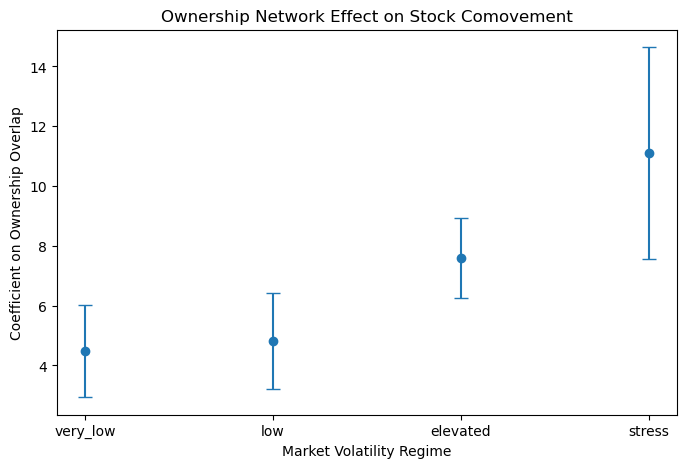

In [24]:
coef_df = pd.DataFrame({
    "vol_group": ["very_low","low","elevated","stress"],
    "beta_overlap": [4.472,4.810,7.585,11.108],
    "se": [1.532,1.601,1.341,3.535]
})

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.errorbar(
    coef_df["vol_group"],
    coef_df["beta_overlap"],
    yerr=coef_df["se"],
    fmt="o",
    capsize=5
)

plt.xlabel("Market Volatility Regime")
plt.ylabel("Coefficient on Ownership Overlap")
plt.title("Ownership Network Effect on Stock Comovement")

plt.show()